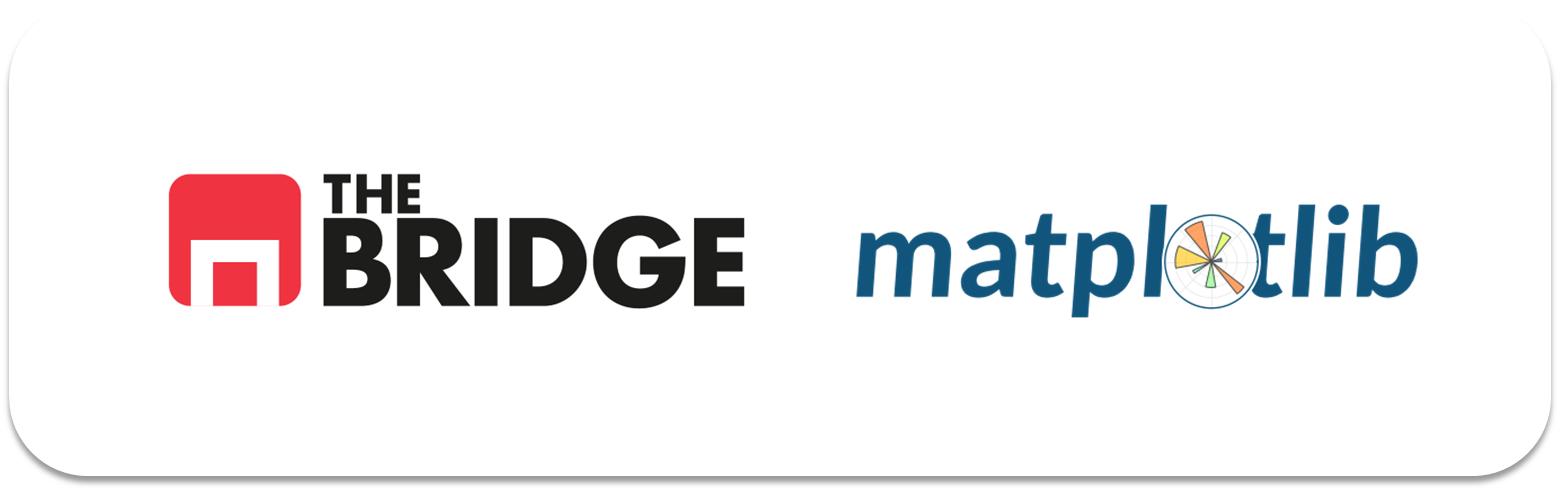

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

pd.options.mode.copy_on_write = True

C:\Users\User\AppData\Local\Temp\ipykernel_7836\2257778423.py:4: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [38]:
df = pd.read_csv('data/california_cities.csv', index_col=0)
df.head()

,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                482 non-null    str    
 1   latd                482 non-null    float64
 2   longd               482 non-null    float64
 3   elevation_m         434 non-null    float64
 4   elevation_ft        470 non-null    float64
 5   population_total    482 non-null    int64  
 6   area_total_sq_mi    480 non-null    float64
 7   area_land_sq_mi     482 non-null    float64
 8   area_water_sq_mi    481 non-null    float64
 9   area_total_km2      477 non-null    float64
 10  area_land_km2       478 non-null    float64
 11  area_water_km2      478 non-null    float64
 12  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(1), str(1)
memory usage: 49.1 KB


In [40]:
df.isna().sum().sort_values(ascending=False)

elevation_m           48
elevation_ft          12
area_water_percent     5
area_total_km2         5
area_water_km2         4
area_land_km2          4
area_total_sq_mi       2
area_water_sq_mi       1
city                   0
latd                   0
longd                  0
area_land_sq_mi        0
population_total       0
dtype: int64

In [41]:
df['elevation_m_from_ft'] = df.elevation_ft * 0.3048

df

,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent,elevation_m_from_ft
0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03,875.0808
1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37,281.0256
2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79,10.0584
3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28,13.1064
4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01,149.9616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,Yountville,38.403056,-122.362222,30.0,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00,29.8704
478,Yreka,41.726667,-122.637500,787.0,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72,786.9936
479,YubaCity,39.134722,-121.626111,18.0,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53,17.9832
480,Yucaipa,34.030278,-117.048611,798.0,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02,797.9664


In [42]:
df['elevation_m']= df['elevation_m'].fillna(df['elevation_m_from_ft'])     ### recuerda los paréntesis

In [43]:
df['elevation_ft']= df['elevation_ft'].fillna(df['elevation_m']/0.3048)

In [44]:
df.isna().sum().sort_values(ascending=False)

elevation_m_from_ft    12
elevation_ft            8
elevation_m             8
area_total_km2          5
area_water_percent      5
area_water_km2          4
area_land_km2           4
area_total_sq_mi        2
area_water_sq_mi        1
latd                    0
population_total        0
longd                   0
city                    0
area_land_sq_mi         0
dtype: int64

In [45]:
df.drop(columns='elevation_m_from_ft',inplace=True)

In [46]:
df

,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,Adelanto,34.576111,-117.432778,875.0000,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,AgouraHills,34.153333,-118.761667,281.0000,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,Alameda,37.756111,-122.274444,10.0584,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,Albany,37.886944,-122.297778,13.1064,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,Alhambra,34.081944,-118.135000,150.0000,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,Yountville,38.403056,-122.362222,30.0000,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00
478,Yreka,41.726667,-122.637500,787.0000,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72
479,YubaCity,39.134722,-121.626111,18.0000,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53
480,Yucaipa,34.030278,-117.048611,798.0000,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02


In [47]:
df = df.dropna()

In [48]:
df.isna().sum().sort_values(ascending=False)

city                  0
latd                  0
longd                 0
elevation_m           0
elevation_ft          0
population_total      0
area_total_sq_mi      0
area_land_sq_mi       0
area_water_sq_mi      0
area_total_km2        0
area_land_km2         0
area_water_km2        0
area_water_percent    0
dtype: int64

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  


In [49]:
df_1 = df[['city','population_total']]

df_1

,city,population_total
0,Adelanto,31765
1,AgouraHills,20330
2,Alameda,75467
3,Albany,18969
4,Alhambra,83089
...,...,...
477,Yountville,2933
478,Yreka,7765
479,YubaCity,64925
480,Yucaipa,51367


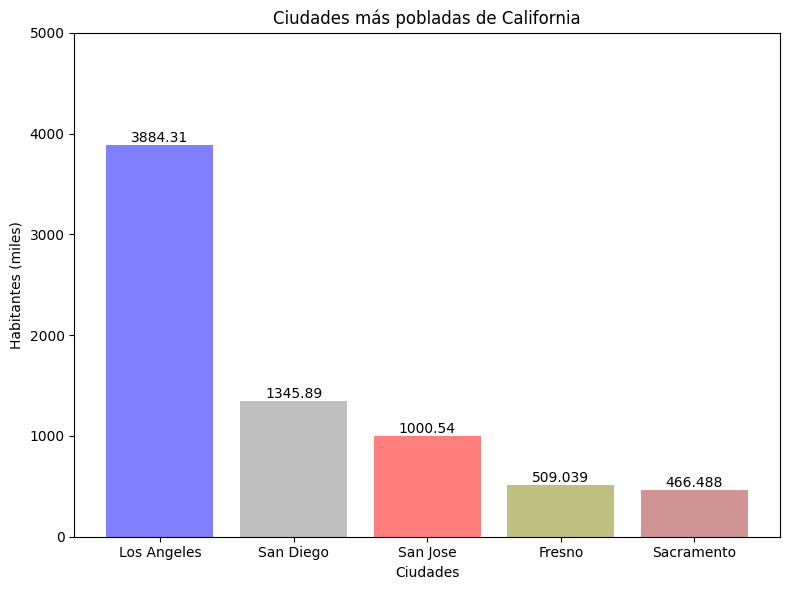

In [50]:
def separar_nombre(nombre):
    nuevo = nombre[0]
    for letra in nombre[1:]:
        if letra == letra.upper():
            nuevo = nuevo + " "
        nuevo = nuevo + letra
    return nuevo                                                            ##### esta parte es de Álex, para separar los nombres

df_1 = df[['city', 'population_total']].copy() 
df_1['city'] = df_1['city'].apply(separar_nombre)                           #### para que separe los nombres

df_1_filtro = df_1.nlargest(5, 'population_total')                          #### ciudades más pobladas


plt.figure(figsize=(8, 6))
bars = plt.bar(df_1_filtro['city'], df_1_filtro['population_total'] / 1000,
               color=['blue', 'gray', 'red', 'olive', 'brown'],
               alpha=0.5)

plt.bar_label(bars)
plt.ylim([0, 5000])
plt.ylabel('Habitantes (miles)')
plt.xlabel('Ciudades')
plt.title('Ciudades más pobladas de California')
plt.tight_layout()
plt.show()

In [51]:
#### print(df['city'].unique()[:10])



# comprobar la forma de escribir los nombres (original)

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")


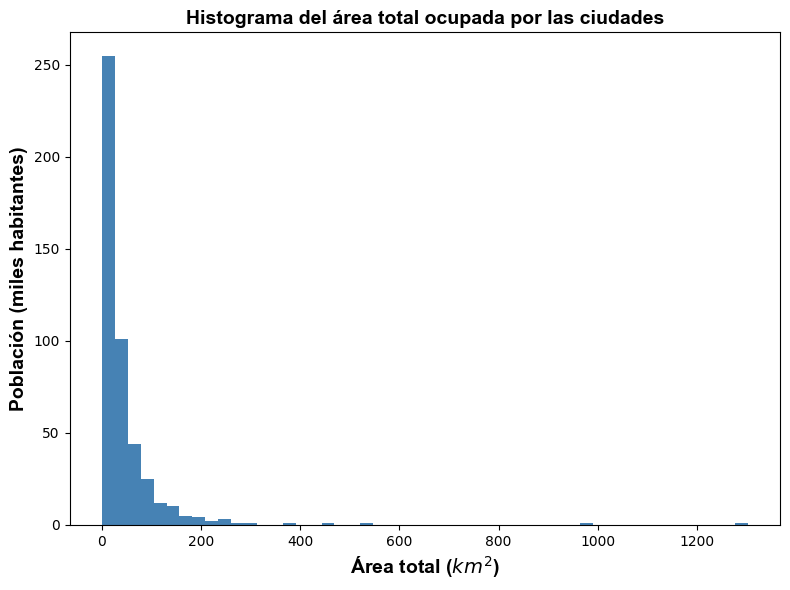

In [52]:
plt.figure(figsize=(8, 6))

plt.hist(df['area_total_km2'], bins=50, color='steelblue')

plt.xlabel('Área total ($km^2$)', fontname='Arial', fontsize=14, fontweight='bold')
plt.ylabel('Población (miles habitantes)', fontname='Arial', fontsize=14, fontweight='bold')
plt.title('Histograma del área total ocupada por las ciudades', fontname='Arial', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [53]:
fontdic = dict(family="Arial",
               size=14,
               fontweight='bold')

### corrección de Álex, para no repetir código durante el formateo

3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.


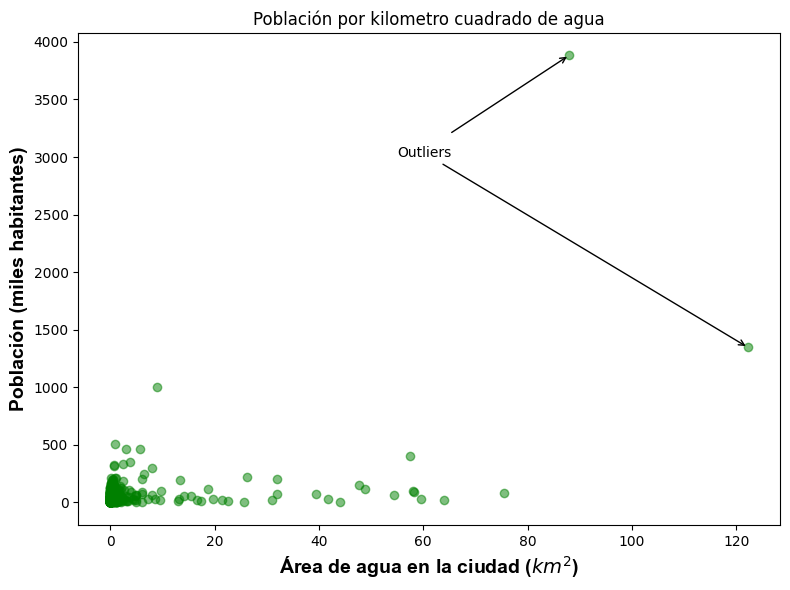

In [83]:
outliers = df.nlargest(2, 'area_water_km2')

plt.figure(figsize=(8, 6))

plt.scatter(df['area_water_km2'], df['population_total'] / 1000,
            alpha=0.5, color='green')

plt.annotate('Outliers',
             xy=(outliers.iloc[0]['area_water_km2'], outliers.iloc[0]['population_total'] / 1000),
             xytext=(55, 3000),
             arrowprops=dict(arrowstyle='->'))

plt.annotate('',
             xy=(outliers.iloc[1]['area_water_km2'], outliers.iloc[1]['population_total'] / 1000),
             xytext=(65, 3200),
             arrowprops=dict(arrowstyle='->'))

plt.xlabel('Área de agua en la ciudad ($km^2$)', fontname='Arial', fontsize=14, fontweight='bold')
plt.ylabel('Población (miles habitantes)', fontname='Arial', fontsize=14, fontweight='bold')
plt.title('Población por kilometro cuadrado de agua')

plt.tight_layout()
plt.show()

In [62]:
outliers = df.nlargest(2, 'area_water_km2')
print(outliers[['city', 'area_water_km2', 'population_total']])

           city  area_water_km2  population_total
367    SanDiego          122.27           1345895
239  LosAngeles           88.00           3884307


In [84]:
outlier_1_y = df_1_filtro['population_total'].nlargest(2).iloc[0]
outlier_2_y = df_1_filtro['population_total'].nlargest(2).iloc[1]
outlier_1_x = df.nlargest(2, 'area_water_km2').iloc[0]['area_water_km2']
outlier_2_x = df.nlargest(2, 'area_water_km2').iloc[1]['area_water_km2']

outlier_1_y, outlier_1_x, outlier_2_x, outlier_2_y


#### corrección de álex

(np.int64(3884307), np.float64(122.27), np.float64(88.0), np.int64(1345895))

4. El boxplot de la altura de las ciudades.

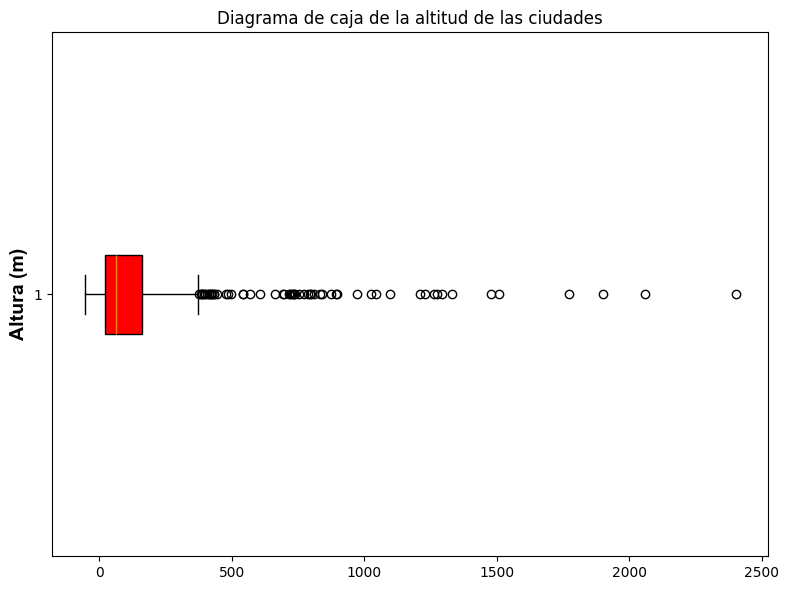

In [91]:
plt.figure(figsize=(8, 6))

bp = plt.boxplot(df['elevation_m'].dropna(), vert=False, patch_artist = True)
bp['boxes'][0].set_facecolor('red')                                           #para imitar el color rojo del ejemplo

plt.ylabel('Altura (m)', fontname='Arial', fontsize=14, fontweight='bold')
plt.title('Diagrama de caja de la altitud de las ciudades')

plt.tight_layout()
plt.show()

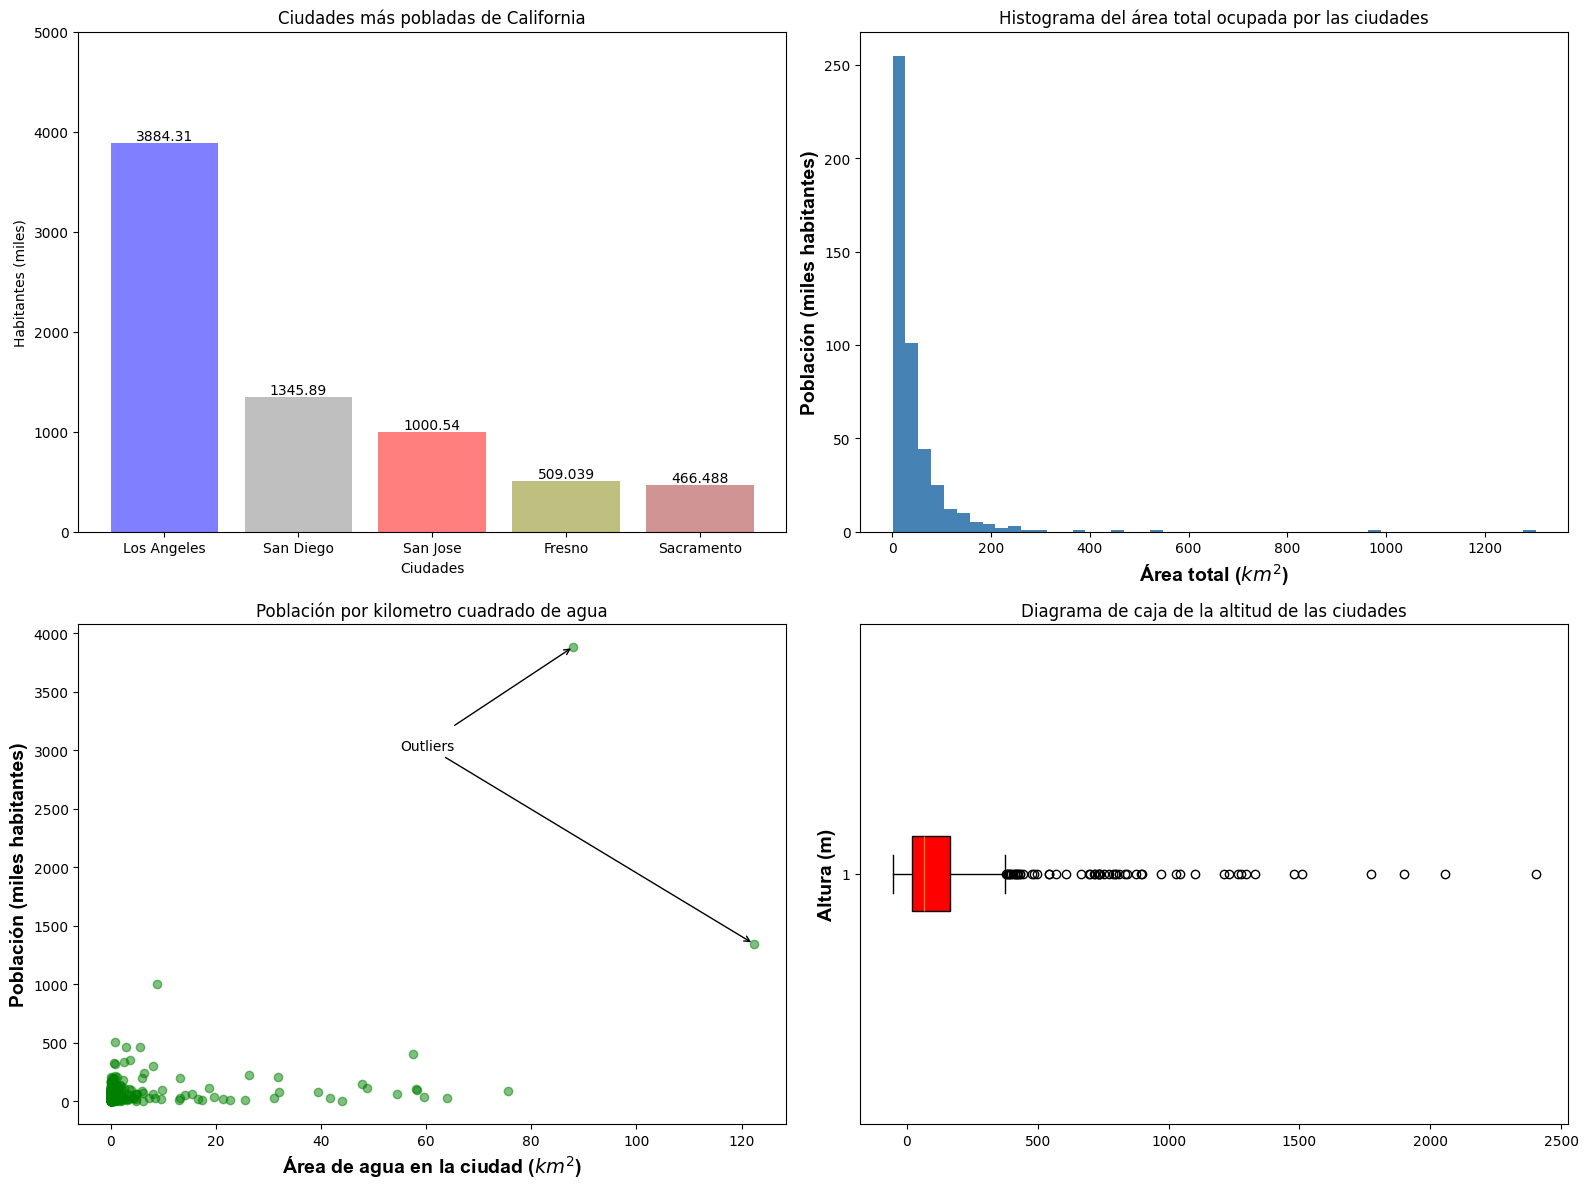

In [ ]:
#### Todas juntas

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

# Gráfico 1: Ciudades más pobladas
primera = axs[0]
bars = primera.bar(df_1_filtro['city'], df_1_filtro['population_total'] / 1000,
               color=['blue', 'gray', 'red', 'olive', 'brown'],
               alpha=0.5)
primera.bar_label(bars)
primera.set_ylim([0, 5000])
primera.set_ylabel('Habitantes (miles)')
primera.set_xlabel('Ciudades')
primera.set_title('Ciudades más pobladas de California')

###  Gráfico 2: Histograma área total
segunda = axs[1]
segunda.hist(df['area_total_km2'], bins=50, color='steelblue')
segunda.set_xlabel('Área total ($km^2$)', fontname='Arial', fontsize=14, fontweight='bold')
segunda.set_ylabel('Población (miles habitantes)', fontname='Arial', fontsize=14, fontweight='bold')
segunda.set_title('Histograma del área total ocupada por las ciudades')

### Gráfico 3: Superficie x km2 de agua
tercera = axs[2]
tercera.scatter(df['54area_water_km2'], df['population_total'] / 1000,
            alpha=0.5, color='green')
tercera.annotate('Outliers',
             xy=(outliers.iloc[0]['area_water_km2'], outliers.iloc[0]['population_total'] / 1000),
             xytext=(55, 3000),
             arrowprops=dict(arrowstyle='->'))
tercera.annotate('',
             xy=(outliers.iloc[1]['area_water_km2'], outliers.iloc[1]['population_total'] / 1000),
             xytext=(65, 3200),
             arrowprops=dict(arrowstyle='->'))
tercera.set_xlabel('Área de agua en la ciudad ($km^2$)', fontname='Arial', fontsize=14, fontweight='bold')
tercera.set_ylabel('Población (miles habitantes)', fontname='Arial', fontsize=14, fontweight='bold')
tercera.set_title('Población por kilometro cuadrado de agua')

### Gráfica 4: Altitud
cuarta = axs[3]
bp = cuarta.boxplot(df['elevation_m'].dropna(), vert=False, patch_artist=True)
bp['boxes'][0].set_facecolor('red')                                           #para imitar el color rojo del ejemplo
cuarta.set_ylabel('Altura (m)', fontname='Arial', fontsize=14, fontweight='bold')
cuarta.set_title('Diagrama de caja de la altitud de las ciudades')

plt.tight_layout()
plt.show()

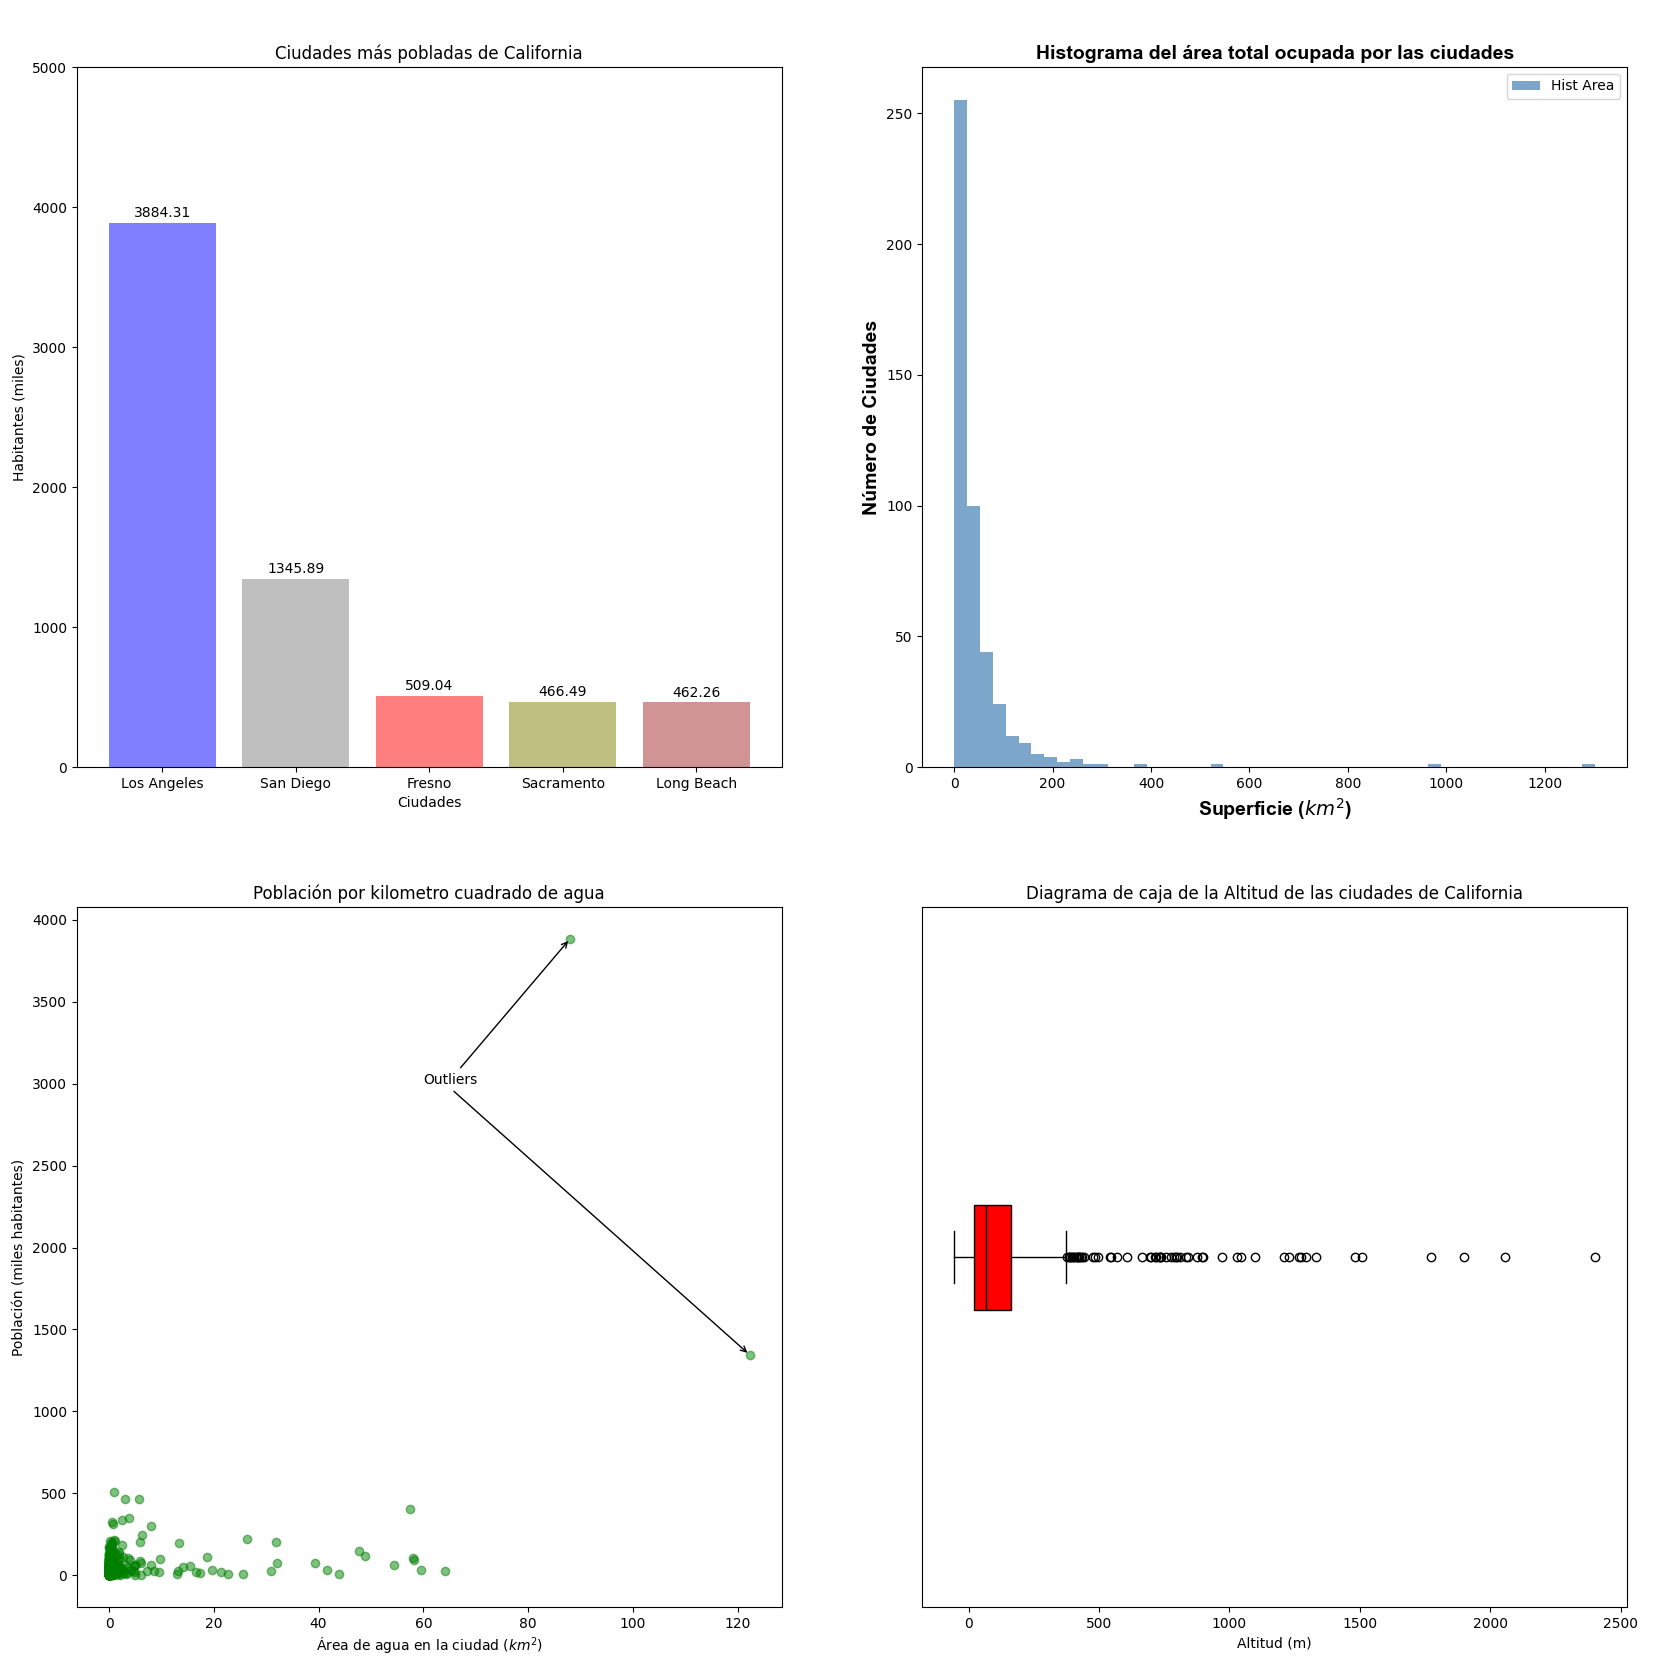

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

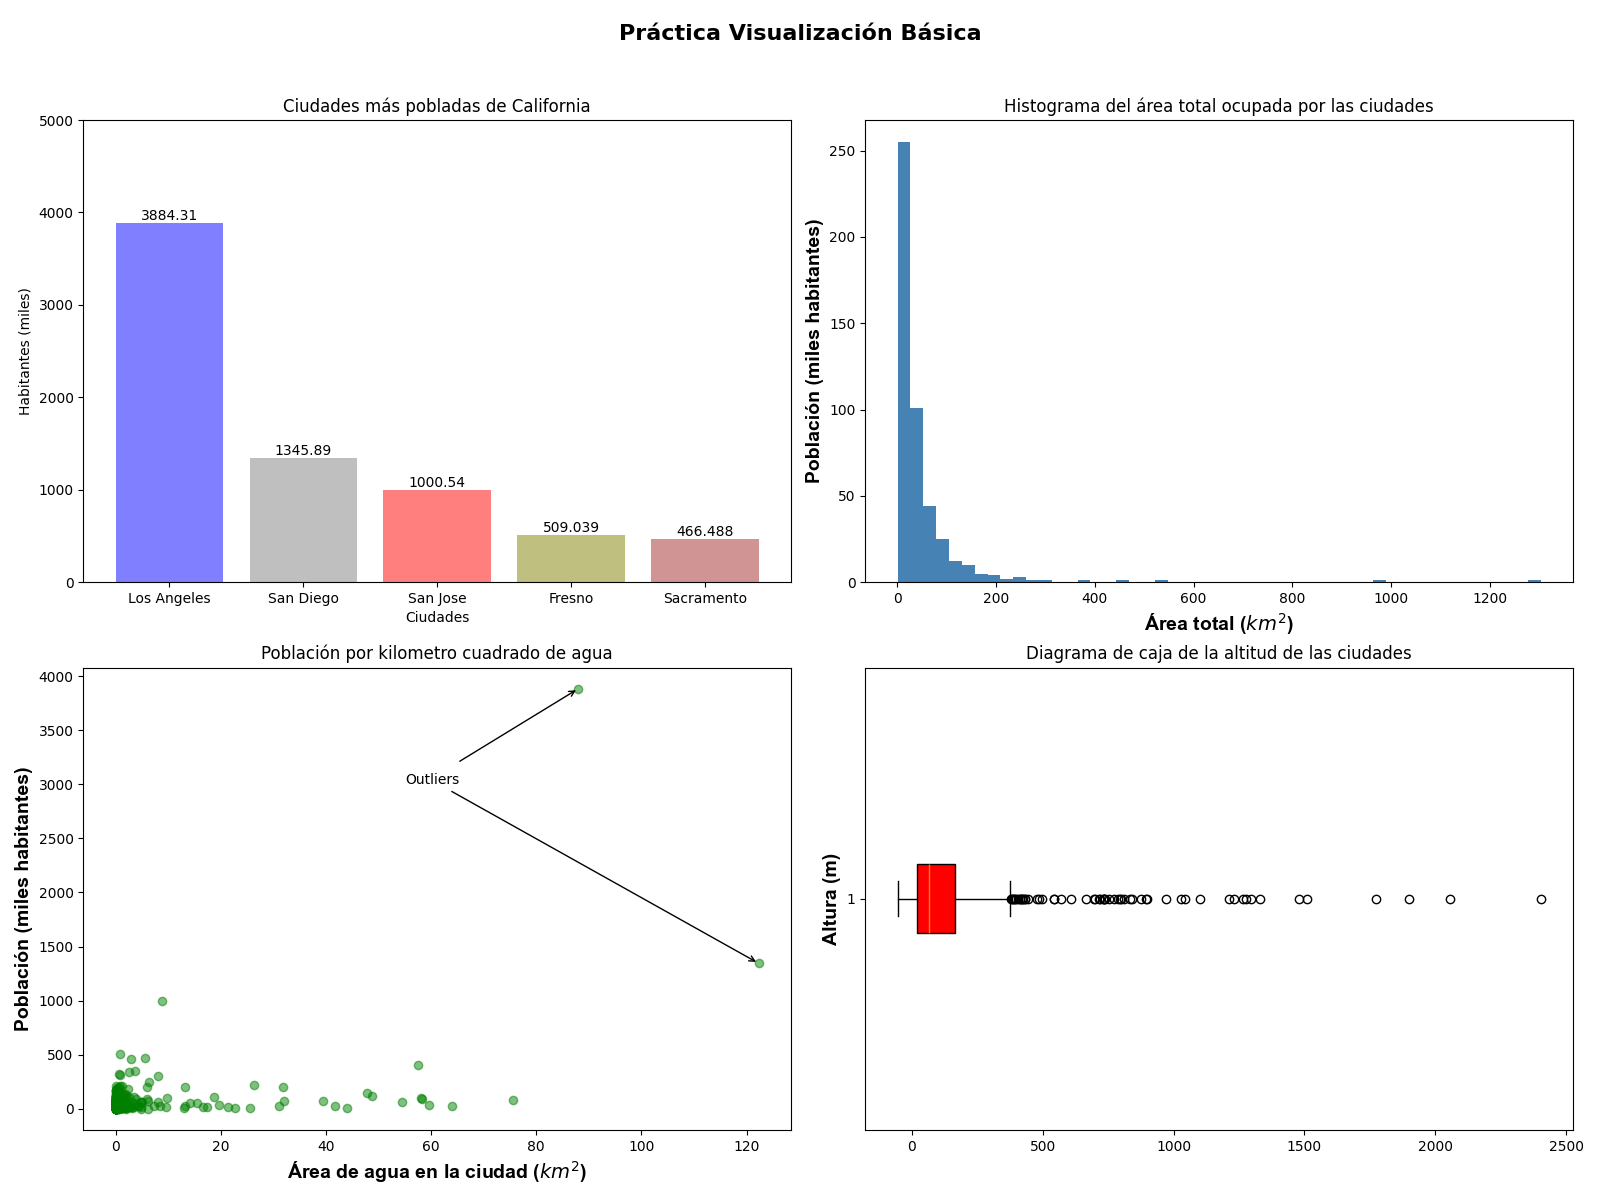

In [113]:
fig.suptitle('Práctica Visualización Básica', fontsize=16, fontweight='bold')           # para poner un titulito
fig.subplots_adjust(top=0.90)                                                           # dejar espacio entre el título y los gráficos                                                                       # previsualiza
fig.savefig("practica_visualizacion_basica.png")                                        # luego guarda


from IPython.display import Image
Image("practica_visualizacion_basica.png")                                              # para visualizar sin abrir el explorador :') 